In [29]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

In [54]:
def simulate_monty_hall(simulations = 100):
    conservative_wins = 0
    switcher_wins= 0
    newcomer_wins = 0
    for i in range(simulations):
        car = r.randint(0,2) #random selection of the car location
        doors = np.zeros(3).astype(int)
        doors[car]=1 #the array represents what is behind the doors (0 = goat, 1 = car)
        initial_choice = r.randint(0,2) #random choice by the player
        #The presenter opens one or the door not selected by the player and with a goat behind
        doors_left_to_open = [num for num in range(3) if num != car and num != initial_choice]
        opened_door = r.choice(doors_left_to_open)
        #the switcher
        switcher_choice = [num for num in range(3) if num != initial_choice and num != opened_door][0]
        #the newcomer
        newcomer_choice = r.choice([initial_choice, switcher_choice])
        
        #check of winning
        if initial_choice == car:
            conservative_wins += 1
        if switcher_choice == car:
            switcher_wins += 1
        if newcomer_choice == car:
            newcomer_wins += 1
            
    return conservative_wins, switcher_wins, newcomer_wins

In [55]:
conservative_wins, switcher_wins, newcomer_wins = simulate_monty_hall()

In [56]:
print(conservative_wins, switcher_wins, newcomer_wins)

43 57 60


In [64]:
conservative_prob = []
switcher_prob = []
newcomer_prob = []
for N in np.linspace(1,10000, 10).astype(int):
    c, s, n = simulate_monty_hall(N)
    conservative_prob.append(c/N)
    switcher_prob.append(s/N)
    newcomer_prob.append(n/N)

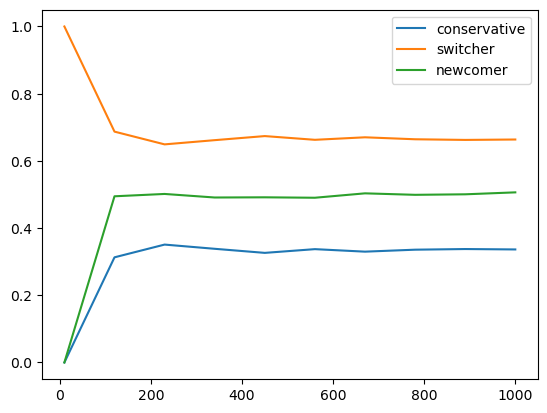

In [66]:
plt.plot(np.linspace(10,1000, 10).astype(int), conservative_prob, label= 'conservative')
plt.plot(np.linspace(10,1000, 10).astype(int), switcher_prob, label='switcher')
plt.plot(np.linspace(10,1000, 10).astype(int), newcomer_prob, label='newcomer')
plt.legend()